<a href="https://colab.research.google.com/github/NidhinGireesh/EpochsDay2/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [12]:
conn = sqlite3.connect("northwind.db")

**Business Question 1**
Top 10 Selling Products

In [13]:
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

tables = cursor.fetchall()

for table in tables:
    print(table[0])

Categories
sqlite_sequence
CustomerCustomerDemo
CustomerDemographics
Customers
Employees
EmployeeTerritories
Order Details
Orders
Products
Regions
Shippers
Suppliers
Territories


In [14]:
query = """
SELECT
    p.ProductName,
    SUM(od.Quantity) AS TotalQuantitySold
FROM "Order Details" od
JOIN Products p
ON od.ProductID = p.ProductID
GROUP BY p.ProductName
ORDER BY TotalQuantitySold DESC
LIMIT 10;
"""

top_products = pd.read_sql_query(query, conn)

top_products

,ProductName,TotalQuantitySold
0,Louisiana Hot Spiced Okra,206213
1,Sir Rodney's Marmalade,205637
2,Teatime Chocolate Biscuits,205487
3,Sirop d'érable,205005
4,Gumbär Gummibärchen,204761
5,Outback Lager,204403
6,Ravioli Angelo,204251
7,Raclette Courdavault,204137
8,Uncle Bob's Organic Dried Pears,203970
9,Sasquatch Ale,203667


In [15]:
top_products.describe()

,TotalQuantitySold
count,10.000000
mean,204753.100000
std,820.692452
min,203667.000000
25%,204165.500000
50%,204582.000000
75%,205366.500000
max,206213.000000


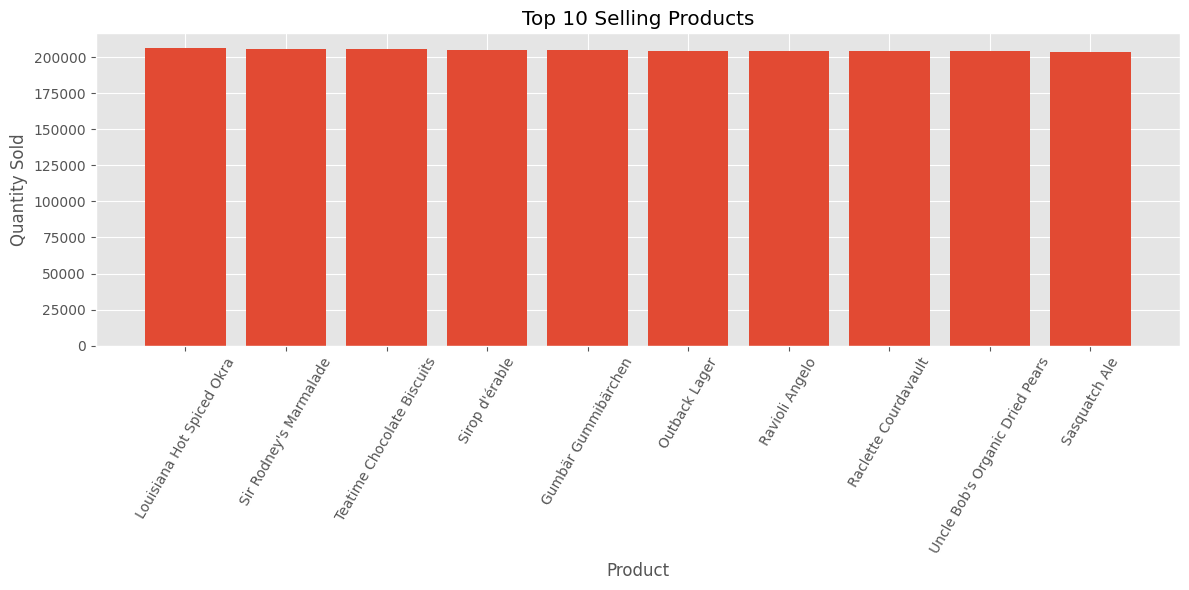

In [16]:
plt.figure(figsize=(12,6))

plt.bar(top_products["ProductName"],
        top_products["TotalQuantitySold"])

plt.xticks(rotation=60)
plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.tight_layout()
plt.show()

**Business Question 2**
Top 10 Customers by Revenue

In [17]:
query2 = """
SELECT
    c.CompanyName,
    ROUND(SUM(od.Quantity * od.UnitPrice),2) AS Revenue
FROM Customers c
JOIN Orders o
ON c.CustomerID = o.CustomerID
JOIN "Order Details" od
ON o.OrderID = od.OrderID
GROUP BY c.CompanyName
ORDER BY Revenue DESC
LIMIT 10;
"""

top_customers = pd.read_sql_query(query2, conn)

top_customers

,CompanyName,Revenue
0,IT,9745371.29
1,B's Beverages,6154115.34
2,Hungry Coyote Import Store,5698023.67
3,Rancho grande,5559110.08
4,Gourmet Lanchonetes,5552597.90
5,Ana Trujillo Emparedados y helados,5534356.65
6,Ricardo Adocicados,5524990.91
7,Folies gourmandes,5505502.85
8,Let's Stop N Shop,5462611.57
9,LILA-Supermercado,5439186.80


In [18]:
top_customers.describe()

,Revenue
count,1.000000e+01
mean,6.017587e+06
std,1.326000e+06
min,5.439187e+06
25%,5.510375e+06
50%,5.543477e+06
75%,5.663295e+06
max,9.745371e+06


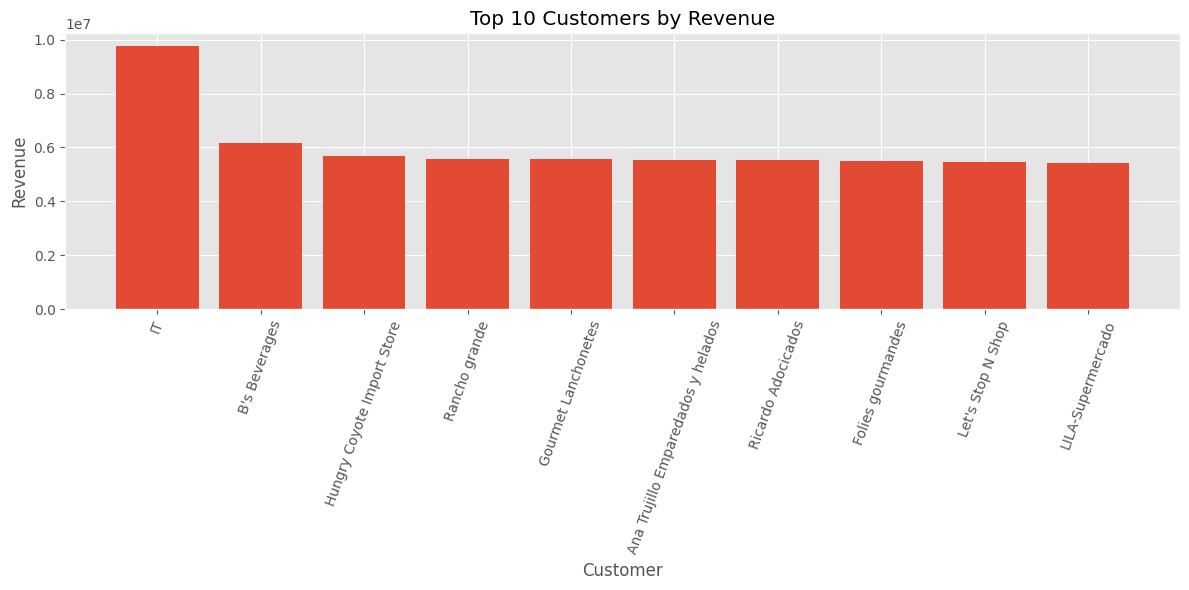

In [19]:
plt.figure(figsize=(12,6))

plt.bar(top_customers["CompanyName"],
        top_customers["Revenue"])

plt.xticks(rotation=70)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()


**Business Question 3**
Monthly Sales Trend

In [20]:
query3 = """
SELECT
    strftime('%Y-%m',o.OrderDate) AS Month,
    ROUND(SUM(od.Quantity*od.UnitPrice),2) AS Sales
FROM Orders o
JOIN "Order Details" od
ON o.OrderID=od.OrderID
GROUP BY Month
ORDER BY Month;
"""

monthly_sales = pd.read_sql_query(query3, conn)

monthly_sales

,Month,Sales
0,2012-07,2066219.40
1,2012-08,3556875.79
2,2012-09,3440144.98
3,2012-10,3201529.96
4,2012-11,2980494.74
5,2012-12,3577936.85
6,2013-01,3075418.29
7,2013-02,2964192.86
8,2013-03,3471361.21
9,2013-04,3262893.52


In [21]:
monthly_sales.describe()

,Sales
count,1.360000e+02
mean,3.297612e+06
std,3.885407e+05
min,2.066219e+06
25%,3.050957e+06
50%,3.286028e+06
75%,3.518739e+06
max,4.377795e+06


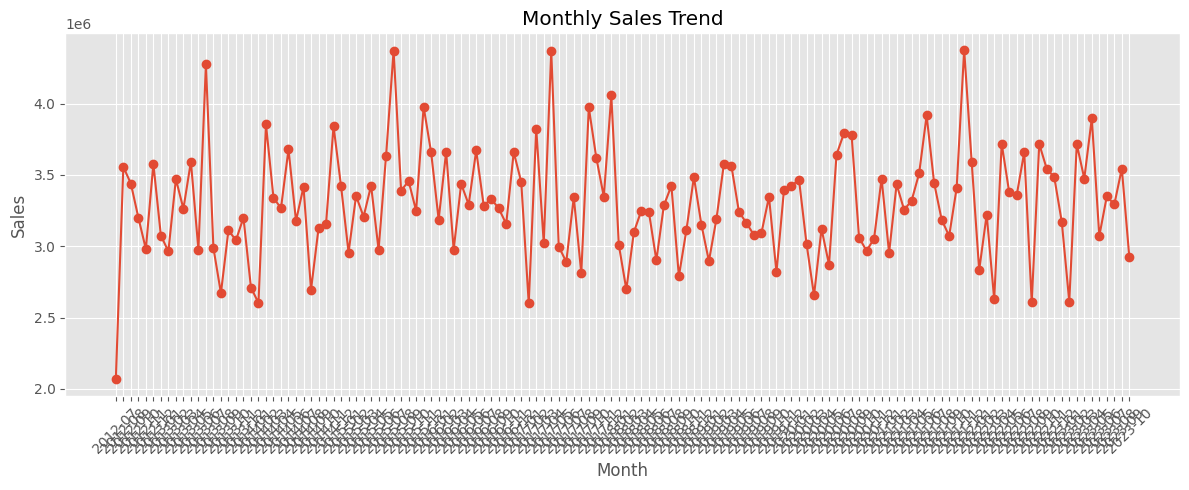

In [22]:
plt.figure(figsize=(12,5))

plt.plot(monthly_sales["Month"],
         monthly_sales["Sales"],
         marker="o")

plt.xticks(rotation=45)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.tight_layout()
plt.show()

**Business Question 4**
Best Performing Categories

In [23]:
query4 = """
SELECT
    c.CategoryName,
    ROUND(SUM(od.Quantity*od.UnitPrice),2) AS Revenue
FROM Categories c
JOIN Products p
ON c.CategoryID=p.CategoryID
JOIN "Order Details" od
ON p.ProductID=od.ProductID
GROUP BY c.CategoryName
ORDER BY Revenue DESC;
"""

categories = pd.read_sql_query(query4, conn)

categories


,CategoryName,Revenue
0,Beverages,92181842.95
1,Confections,66347544.94
2,Meat/Poultry,64896314.41
3,Dairy Products,58034940.00
4,Condiments,55802774.45
5,Seafood,49931965.52
6,Produce,32706403.90
7,Grains/Cereals,28573512.55


In [24]:
categories.describe()

,Revenue
count,8.000000e+00
mean,5.605941e+07
std,2.011083e+07
min,2.857351e+07
25%,4.562558e+07
50%,5.691886e+07
75%,6.525912e+07
max,9.218184e+07


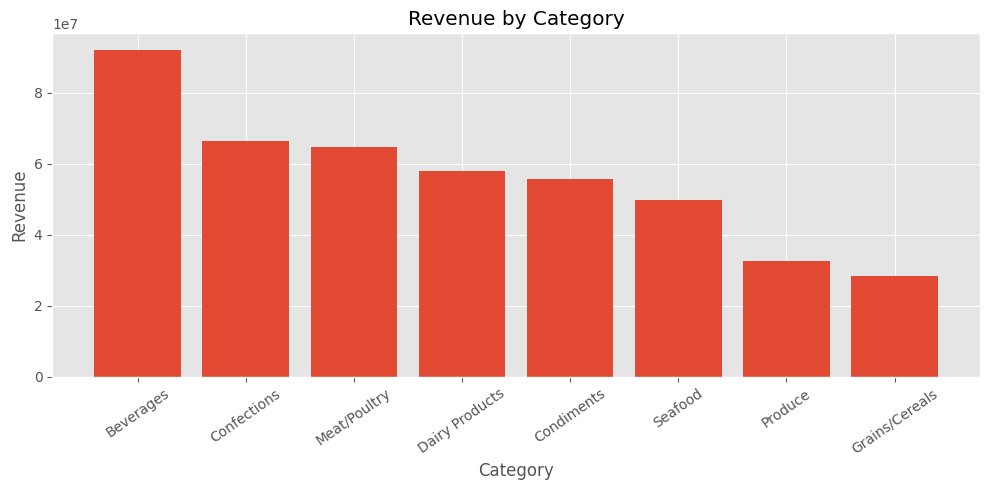

In [25]:
plt.figure(figsize=(10,5))

plt.bar(categories["CategoryName"],
        categories["Revenue"])

plt.xticks(rotation=35)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

**Business Question 5**
Customer Purchase Frequency

In [26]:
query5 = """
SELECT
    c.CompanyName,
    COUNT(o.OrderID) AS NumberOfOrders
FROM Customers c
JOIN Orders o
ON c.CustomerID=o.CustomerID
GROUP BY c.CompanyName
ORDER BY NumberOfOrders DESC;
"""

purchase_frequency = pd.read_sql_query(query5, conn)

purchase_frequency

,CompanyName,NumberOfOrders
0,IT,335
1,B's Beverages,210
2,Ricardo Adocicados,203
3,LILA-Supermercado,203
4,Gourmet Lanchonetes,202
5,Princesa Isabel Vinhos,200
6,Hungry Coyote Import Store,198
7,Tortuga Restaurante,197
8,Folies gourmandes,195
9,Ana Trujillo Emparedados y helados,195


In [27]:
purchase_frequency.describe()

,NumberOfOrders
count,92.000000
mean,176.978261
std,20.942086
min,154.000000
25%,165.750000
50%,175.000000
75%,184.250000
max,335.000000


<Figure size 1200x600 with 0 Axes>

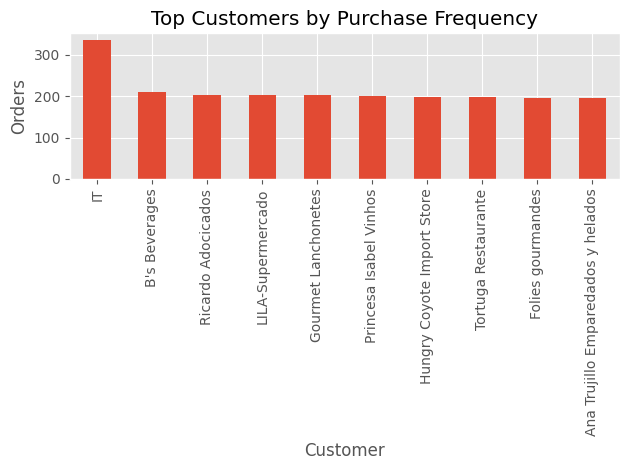

In [28]:
plt.figure(figsize=(12,6))

purchase_frequency.head(10).plot(
    x="CompanyName",
    y="NumberOfOrders",
    kind="bar",
    legend=False
)

plt.title("Top Customers by Purchase Frequency")
plt.xlabel("Customer")
plt.ylabel("Orders")

plt.tight_layout()
plt.show()

**Exploratory Data Analysis**

In [29]:
print("Top Products")
display(top_products.head())

print("Top Customers")
display(top_customers.head())

print("Monthly Sales")
display(monthly_sales.head())

print("Categories")
display(categories.head())

print("Purchase Frequency")
display(purchase_frequency.head())

Top Products


,ProductName,TotalQuantitySold
0,Louisiana Hot Spiced Okra,206213
1,Sir Rodney's Marmalade,205637
2,Teatime Chocolate Biscuits,205487
3,Sirop d'érable,205005
4,Gumbär Gummibärchen,204761


Top Customers


,CompanyName,Revenue
0,IT,9745371.29
1,B's Beverages,6154115.34
2,Hungry Coyote Import Store,5698023.67
3,Rancho grande,5559110.08
4,Gourmet Lanchonetes,5552597.90


Monthly Sales


,Month,Sales
0,2012-07,2066219.40
1,2012-08,3556875.79
2,2012-09,3440144.98
3,2012-10,3201529.96
4,2012-11,2980494.74


Categories


,CategoryName,Revenue
0,Beverages,92181842.95
1,Confections,66347544.94
2,Meat/Poultry,64896314.41
3,Dairy Products,58034940.00
4,Condiments,55802774.45


Purchase Frequency


,CompanyName,NumberOfOrders
0,IT,335
1,B's Beverages,210
2,Ricardo Adocicados,203
3,LILA-Supermercado,203
4,Gourmet Lanchonetes,202


In [30]:
print("Top Products Summary")
print(top_products.describe())

print("\nTop Customers Summary")
print(top_customers.describe())

print("\nMonthly Sales Summary")
print(monthly_sales.describe())

print("\nCategories Summary")
print(categories.describe())

print("\nPurchase Frequency Summary")
print(purchase_frequency.describe())

Top Products Summary
       TotalQuantitySold
count          10.000000
mean       204753.100000
std           820.692452
min        203667.000000
25%        204165.500000
50%        204582.000000
75%        205366.500000
max        206213.000000

Top Customers Summary
            Revenue
count  1.000000e+01
mean   6.017587e+06
std    1.326000e+06
min    5.439187e+06
25%    5.510375e+06
50%    5.543477e+06
75%    5.663295e+06
max    9.745371e+06

Monthly Sales Summary
              Sales
count  1.360000e+02
mean   3.297612e+06
std    3.885407e+05
min    2.066219e+06
25%    3.050957e+06
50%    3.286028e+06
75%    3.518739e+06
max    4.377795e+06

Categories Summary
            Revenue
count  8.000000e+00
mean   5.605941e+07
std    2.011083e+07
min    2.857351e+07
25%    4.562558e+07
50%    5.691886e+07
75%    6.525912e+07
max    9.218184e+07

Purchase Frequency Summary
       NumberOfOrders
count       92.000000
mean       176.978261
std         20.942086
min        154.000000
25%       